In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


In [ ]:
filepath= os.path.join (path,'heart.csv')
df=pd.read_csv(filepath)

In [ ]:
df_copy=df

In [ ]:
cat = df.select_dtypes(include=["object"]).columns.tolist()

In [ ]:
cat

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [ ]:
df_copy= pd.get_dummies(df,columns=cat,drop_first=True)

In [ ]:
x=df_copy.drop('HeartDisease',axis=1)
y=df_copy['HeartDisease']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier()
model.fit(x_train,y_train)

AdaBoostClassifier()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
model.score(x_train,y_train)

0.8869209809264306

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8586956521739131
[[68  9]
 [17 90]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [ ]:
print(accuracy_score(y_train, model.predict(x_train)))

0.8869209809264306


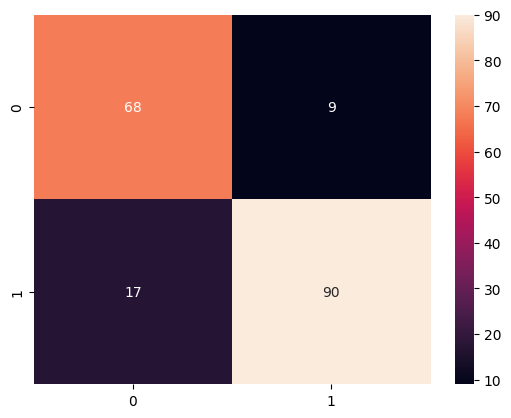

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.show()

In [ ]:
#skewness ->log transformation se thik karte h
#standard scaler ->mean =0 , stddeviation =1, after traning -> inverse transformation

In [ ]:
print(f"Shape of df: {df.shape}")
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of df: (918, 12)
Shape of x_train: (734, 15)
Shape of y_train: (734,)
